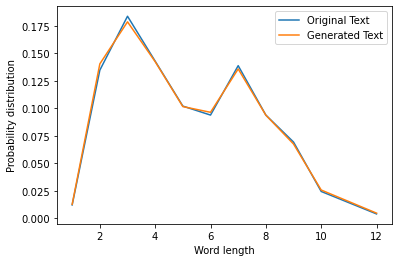

In [4]:
import regex as re
import random as rand
import matplotlib.pyplot as plt

def read_file():
    with open("/Users/jeevan/Downloads/files/simple-english-wikipedia.txt", "r") as file:
        text = file.read()
    return text

def word_length_distribution(clean_text):
    
    word_length_distribution = {}
    word_length_freq_prob = {}
    
    total_words = len(clean_text)
    
    for word in clean_text:
        
        word_length = len(word)
        
        if word_length not in word_length_distribution:
            word_length_distribution[word_length] = 0
        word_length_distribution[word_length] += 1
    
    sum_of_prob = 0
    
    for word_len, word_count in word_length_distribution.items():
        
        abc = word_count / total_words
        word_length_distribution[word_len] = abc
        sum_of_prob += abc
        word_length_freq_prob[word_len] = sum_of_prob
        
    word_length_distribution = dict(sorted(word_length_distribution.items()))
    
    return word_length_distribution, word_length_freq_prob

def character_distribution(clean_text):
    character_frequency = {}  
    character_frequency_probability = {}  
   
    for word in clean_text:        
        for c in word:
            if c in character_frequency:
                character_frequency[c] += 1
            else:
                character_frequency[c] = 1
                
    total = sum(character_frequency.values())
    
    sum_of_prob = 0
    for word_len in character_frequency.keys():
        sum_of_prob += (character_frequency[word_len] / total)  
        character_frequency_probability[word_len] = sum_of_prob
    return character_frequency_probability


def random_word_length(word_len_dist, random_num):
    for word_length in word_len_dist.keys():
        if random_num < word_len_dist[word_length]:
            return word_length

def random_characters(char_dist, random_num):
    for char in char_dist.keys():
        if random_num < char_dist[char]:
            return char

def generate_text(word_len_distribution, char_distribution):
    
    text_words = []
    for i in range(0, 5000):
        random_num = rand.random()  
        word_length = random_word_length(word_len_distribution, random_num)
        
        word = ''
       
        for j in range(0, word_length):
            random_num = rand.random()
            char = random_characters(char_distribution, random_num)
            word += char
        text_words.append(word)
    return text_words

def plot_graph(org_text_dist, gen_text_dist):
    plt.plot(org_text_dist.keys(),org_text_dist.values(), label="Original Text")
    plt.plot(gen_text_dist.keys(),gen_text_dist.values(),label="Generated Text")
    plt.legend()
    plt.xlabel('Word length')
    plt.ylabel('Probability distribution')

if __name__ == "__main__":
    
    text = read_file()
    text = text.lower().replace(',', '')
    clean_text = re.findall(r'[a-z]*[0-9]*',text)
    while("" in clean_text):
        clean_text.remove("")
       
    #print(clean_text)
    
    word_length_dist, word_length_freq_probab = word_length_distribution(clean_text)
    #print(word_length_dist)
    
    character_dist = character_distribution(clean_text)
    #print(character_dist)
    
    num = 5000
    generated_text = generate_text(word_length_freq_probab, character_dist)
    
    with open("output_assignment7WS.txt", "w") as f:
        for word in generated_text:
            f.write(word+" ")
        
    gentext_dist, gen_freq_dist = word_length_distribution(generated_text)
    #print("gentext_dist", gentext_dist)

    while("" in gentext_dist):
        gentext_dist.remove("")
    
    plot_graph(word_length_dist, gentext_dist)
    
   
    